# ScpTensor 主教程（按当前模块）

本教程覆盖当前代码库的主线模块：

1. `scptensor.io`：DIA-NN / Spectronaut 导入（long + matrix）
2. `scptensor.aggregation`：肽段/前体 -> 蛋白聚合
3. `scptensor.qc`：样本与特征 QC
4. `scptensor.transformation` + `scptensor.normalization` + `scptensor.impute`
5. `scptensor.dim_reduction` + `scptensor.cluster`
6. `scptensor.viz`：流程级可视化

说明：主流程遵循“**蛋白层为下游主分析层**”，仅在 aggregation 阶段处理肽段层数据。


## 0. 导入 API

主教程聚焦预处理主线；AutoSelect 见 `tutorial/autoselect_tutorial.ipynb`。


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.sparse as sp

from scptensor import (
    calculate_feature_qc_metrics,
    calculate_sample_qc_metrics,
    filter_features_by_missingness,
    filter_low_quality_samples,
    impute_knn,
    log_transform,
    norm_median,
)
from scptensor.experimental import cluster_kmeans, reduce_pca, reduce_umap
from scptensor.io import (
    aggregate_to_protein,
    load_diann,
    load_peptide_pivot,
    load_quant_table,
    load_spectronaut,
)
from scptensor.viz import (
    plot_data_overview,
    plot_embedding_panels,
    plot_missingness_reduction,
    plot_preprocessing_summary,
    plot_qc_filtering_summary,
    plot_recent_operations,
    plot_reduction_summary,
)

## 1. 定位示例数据（DIA-NN）

In [2]:
def locate_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root")


def pick_diann_report(root: Path) -> Path:
    preferred = root / "data" / "dia" / "diann" / "PXD054343" / "1_SC_LF_report.tsv"
    if preferred.exists():
        return preferred

    candidates = sorted((root / "data" / "dia" / "diann").rglob("*report.tsv"))
    if not candidates:
        raise FileNotFoundError("No DIA-NN report found under data/dia/diann")
    return candidates[0]


ROOT = locate_project_root()
DIANN_REPORT = pick_diann_report(ROOT)
OUT_DIR = ROOT / "tutorial" / "_tutorial_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"DIA-NN report: {DIANN_REPORT.relative_to(ROOT)}")

Project root: /home/shenshang/projects/ScpTensor
DIA-NN report: data/dia/diann/PXD054343/1_SC_LF_report.tsv


## 2. I/O 模块：统一入口与厂商入口

- `load_quant_table`：自动识别软件/表型
- `load_diann`：DIA-NN 直达入口


auto assays: ['proteins']
diann assays: ['proteins']
auto shape: 24 x 2719
diann shape: 24 x 2719


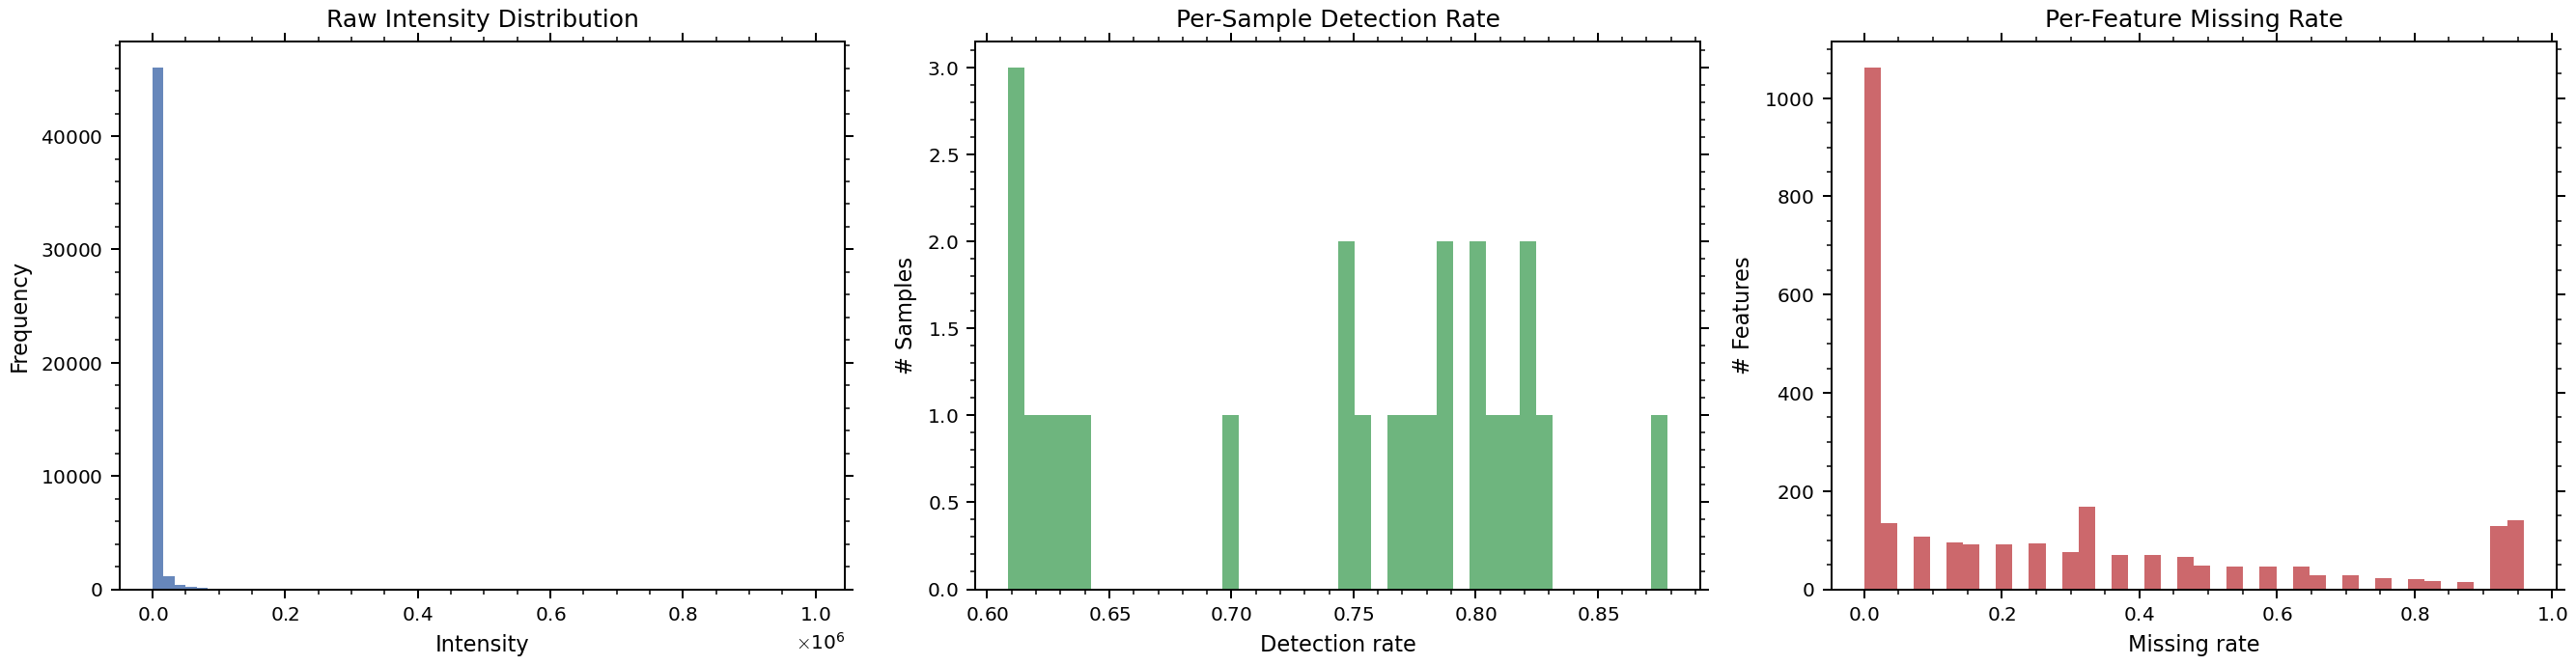

In [3]:
container_auto = load_quant_table(DIANN_REPORT, software="auto", level="protein")
container_diann = load_diann(DIANN_REPORT, level="protein")

print("auto assays:", list(container_auto.assays.keys()))
print("diann assays:", list(container_diann.assays.keys()))
print("auto shape:", container_auto.n_samples, "x", container_auto.assays["proteins"].n_features)
print("diann shape:", container_diann.n_samples, "x", container_diann.assays["proteins"].n_features)

assert container_auto.n_samples == container_diann.n_samples
assert container_auto.assays["proteins"].n_features == container_diann.assays["proteins"].n_features

plot_data_overview(container_diann, assay_name="proteins", layer="raw", groupby="cell_cycle")
plt.show()

## 3. Aggregation 模块：肽段层 -> 蛋白层

先读取肽段层，再聚合到蛋白层，得到完整蛋白定量矩阵。


In [4]:
def to_dense(x: np.ndarray | sp.spmatrix) -> np.ndarray:
    return x.toarray() if sp.issparse(x) else np.asarray(x)


peptide_container = load_diann(
    DIANN_REPORT, level="peptide", table_format="long", assay_name="peptides"
)
container = aggregate_to_protein(
    peptide_container,
    source_assay="peptides",
    source_layer="raw",
    target_assay="proteins",
    method="top_n",
    top_n=3,
    top_n_aggregate="median",
)

x_protein = to_dense(container.assays["proteins"].layers["raw"].X)
print("assays:", list(container.assays.keys()))
print("protein matrix shape:", x_protein.shape)
print(f"protein missing rate: {np.mean(~np.isfinite(x_protein)):.2%}")

assays: ['peptides', 'proteins']
protein matrix shape: (24, 3248)
protein missing rate: 22.99%


## 4. I/O 模块补充：Spectronaut 与 `load_peptide_pivot`（最小可运行示例）

仓库默认数据目录主要是 DIA-NN，这里用小型 toy 表演示 Spectronaut 入口。


In [5]:
toy_sn_protein = pl.DataFrame(
    {
        "PG.ProteinGroups": ["P1", "P1", "P2", "P2"],
        "R.FileName": ["S1.raw", "S2.raw", "S1.raw", "S2.raw"],
        "PG.Quantity": [100.0, 120.0, 50.0, 60.0],
        "PG.Qvalue": [0.005, 0.009, 0.007, 0.02],
    }
)

sn_protein_path = OUT_DIR / "toy_spectronaut_protein_long.tsv"
toy_sn_protein.write_csv(sn_protein_path, separator="	")

sn_container = load_spectronaut(
    sn_protein_path, level="protein", table_format="long", fdr_threshold=0.01
)
print("Spectronaut protein assays:", list(sn_container.assays.keys()))
print(
    "Spectronaut protein shape:",
    sn_container.n_samples,
    "x",
    sn_container.assays["proteins"].n_features,
)


toy_sn_peptide = pl.DataFrame(
    {
        "EG.PrecursorId": ["pep1", "pep2", "pep3"],
        "PG.ProteinGroups": ["P1", "P1", "P2"],
        "S1.raw_Quantity": [1.0, 3.0, 5.0],
        "S2.raw_Quantity": [2.0, 4.0, None],
    }
)

sn_peptide_path = OUT_DIR / "toy_spectronaut_peptide_matrix.tsv"
toy_sn_peptide.write_csv(sn_peptide_path, separator="	")

pivot_container = load_peptide_pivot(
    sn_peptide_path,
    software="spectronaut",
    assay_name="peptides",
    protein_agg=True,
    protein_assay_name="proteins",
    agg_method="sum",
)
print("load_peptide_pivot assays:", list(pivot_container.assays.keys()))

Spectronaut protein assays: ['proteins']
Spectronaut protein shape: 2 x 2
load_peptide_pivot assays: ['peptides', 'proteins']


## 5. QC 模块（`qc_sample` + `qc_feature`）

Samples: 24 -> 24
Features: 3248 -> 2955


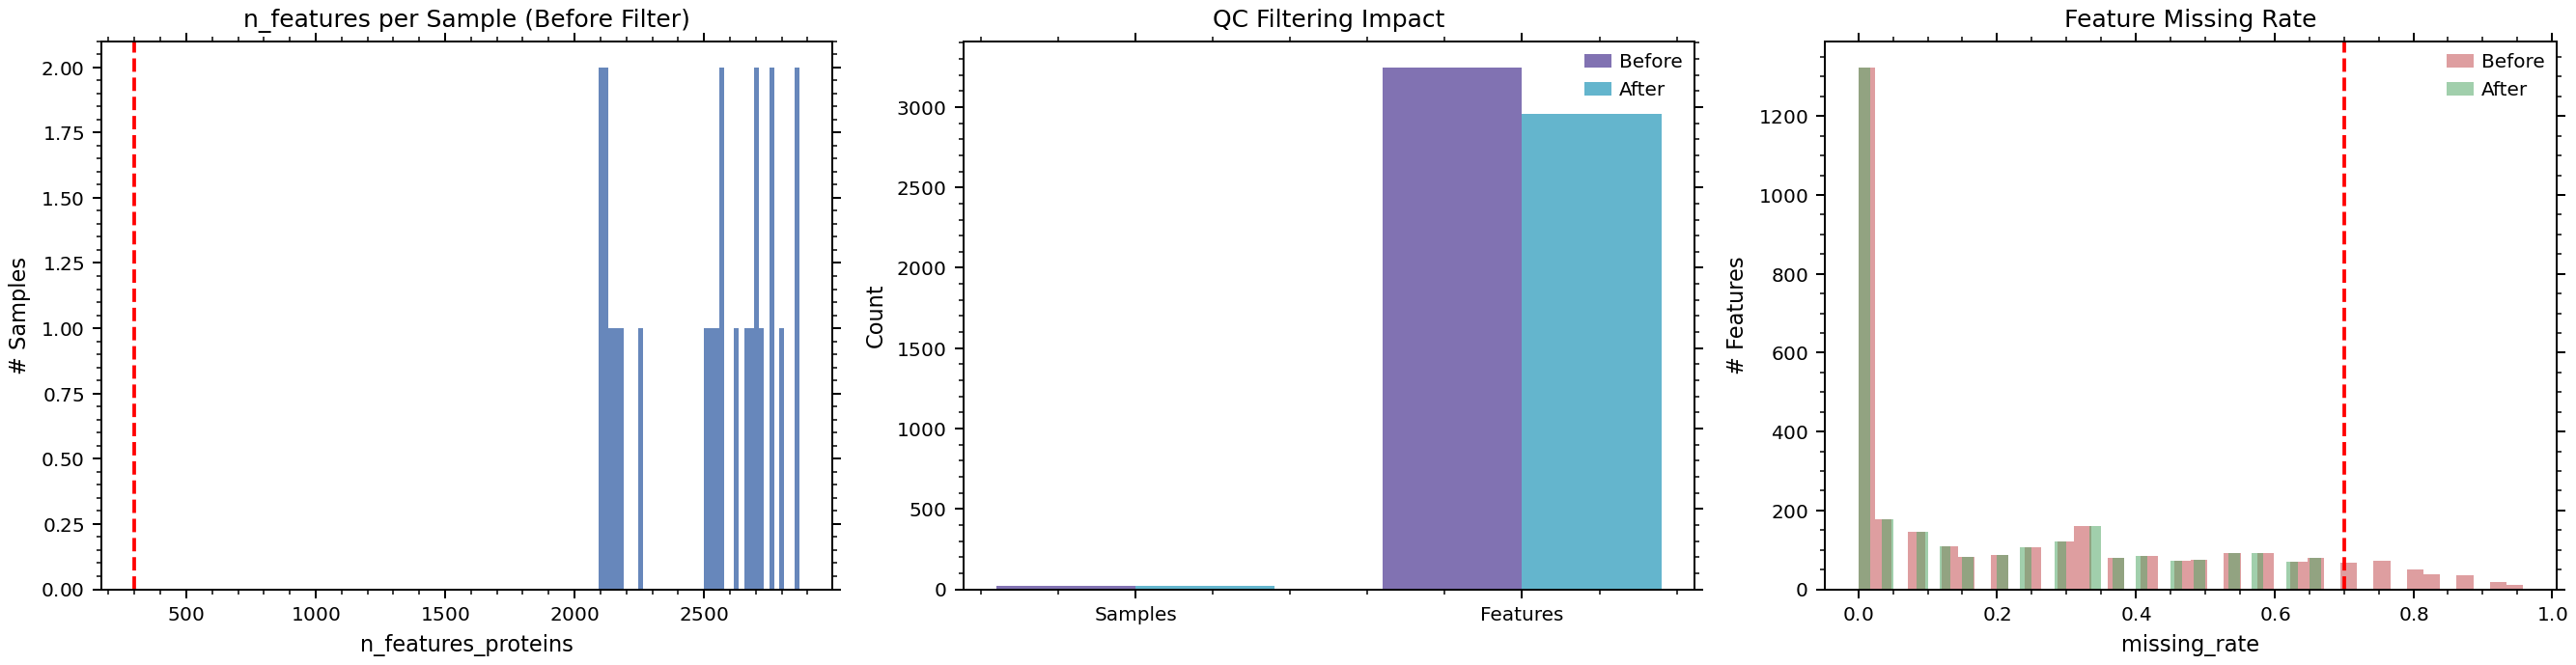

In [6]:
container = calculate_sample_qc_metrics(container, assay_name="proteins", layer_name="raw")
container = calculate_feature_qc_metrics(container, assay_name="proteins", layer_name="raw")

container_before_qc = container.copy()
before_samples = container_before_qc.n_samples
before_features = container_before_qc.assays["proteins"].n_features

container = filter_low_quality_samples(
    container,
    assay_name="proteins",
    min_features=300,
    nmads=3.0,
    use_mad=True,
)
container = filter_features_by_missingness(
    container,
    assay_name="proteins",
    layer_name="raw",
    max_missing_rate=0.70,
)

after_samples = container.n_samples
after_features = container.assays["proteins"].n_features
print(f"Samples: {before_samples} -> {after_samples}")
print(f"Features: {before_features} -> {after_features}")

plot_qc_filtering_summary(
    container_before_qc,
    container,
    assay_name="proteins",
    layer="raw",
    min_features=300,
    max_missing_rate=0.70,
)
plt.show()

## 6. 预处理模块（transform + normalize + impute）

Missing rate before impute: 17.43%
Missing rate after  impute: 0.00%


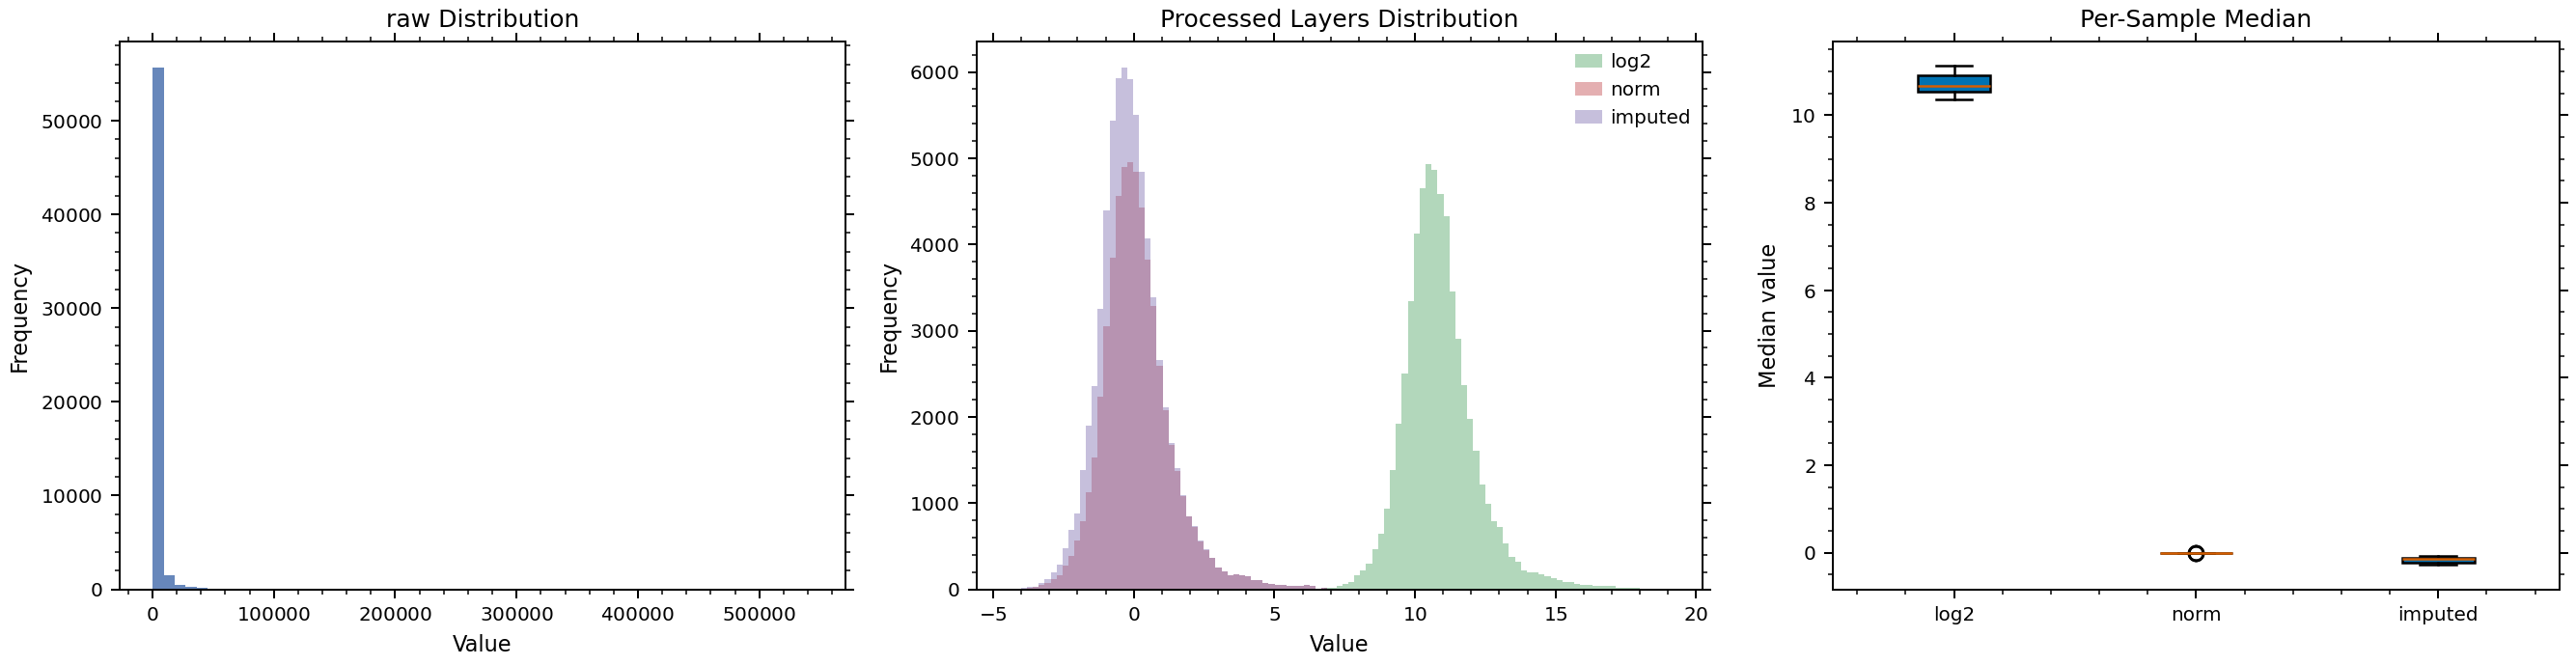

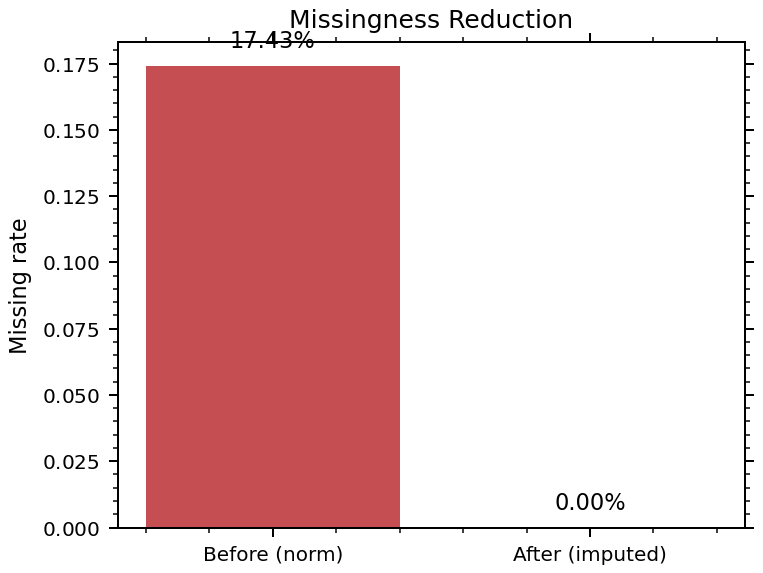

In [7]:
container = log_transform(
    container,
    assay_name="proteins",
    source_layer="raw",
    new_layer_name="log2",
    base=2.0,
)
container = norm_median(
    container,
    assay_name="proteins",
    source_layer="log2",
    new_layer_name="norm",
)

before_impute = np.mean(~np.isfinite(to_dense(container.assays["proteins"].layers["norm"].X)))

container = impute_knn(
    container,
    assay_name="proteins",
    source_layer="norm",
    new_layer_name="imputed",
    k=5,
)

after_impute = np.mean(~np.isfinite(to_dense(container.assays["proteins"].layers["imputed"].X)))

print(f"Missing rate before impute: {before_impute:.2%}")
print(f"Missing rate after  impute: {after_impute:.2%}")

plot_preprocessing_summary(
    container,
    assay_name="proteins",
    raw_layer="raw",
    transformed_layers=("log2", "norm", "imputed"),
)
plot_missingness_reduction(
    container,
    assay_name="proteins",
    before_layer="norm",
    after_layer="imputed",
)
plt.show()

## 7. 降维与聚类模块（dim_reduction + cluster）

/home/shenshang/projects/ScpTensor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shenshang/projects/ScpTensor/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


shape: (4, 2)
┌───────────┬───────┐
│ kmeans_k4 ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ 3         ┆ 4     │
│ 0         ┆ 8     │
│ 2         ┆ 4     │
│ 1         ┆ 8     │
└───────────┴───────┘


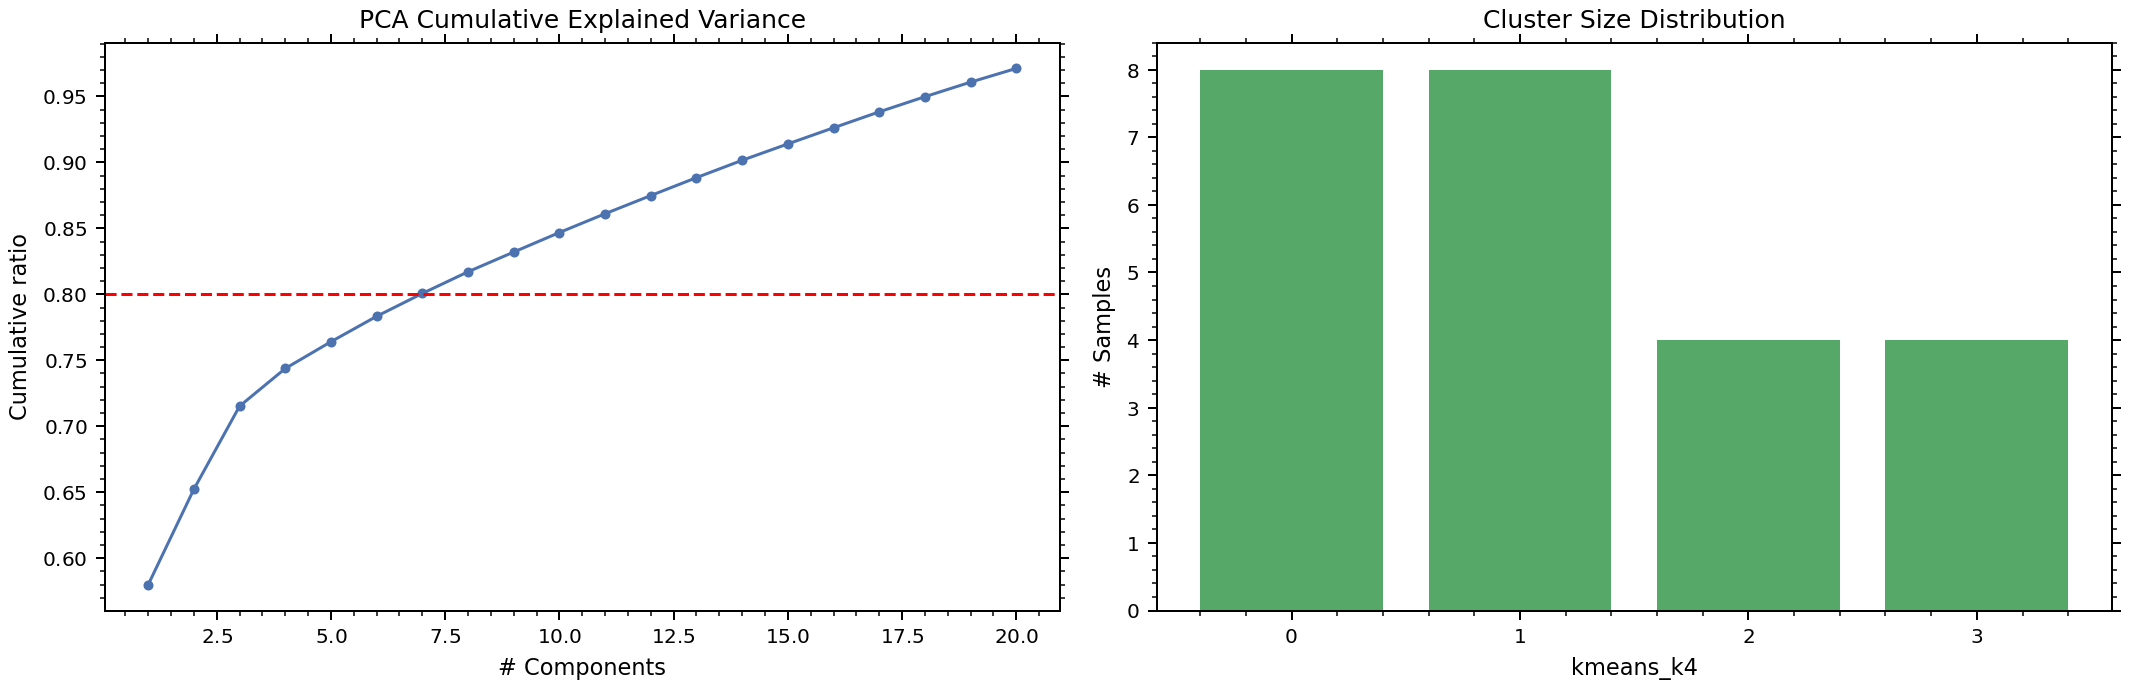

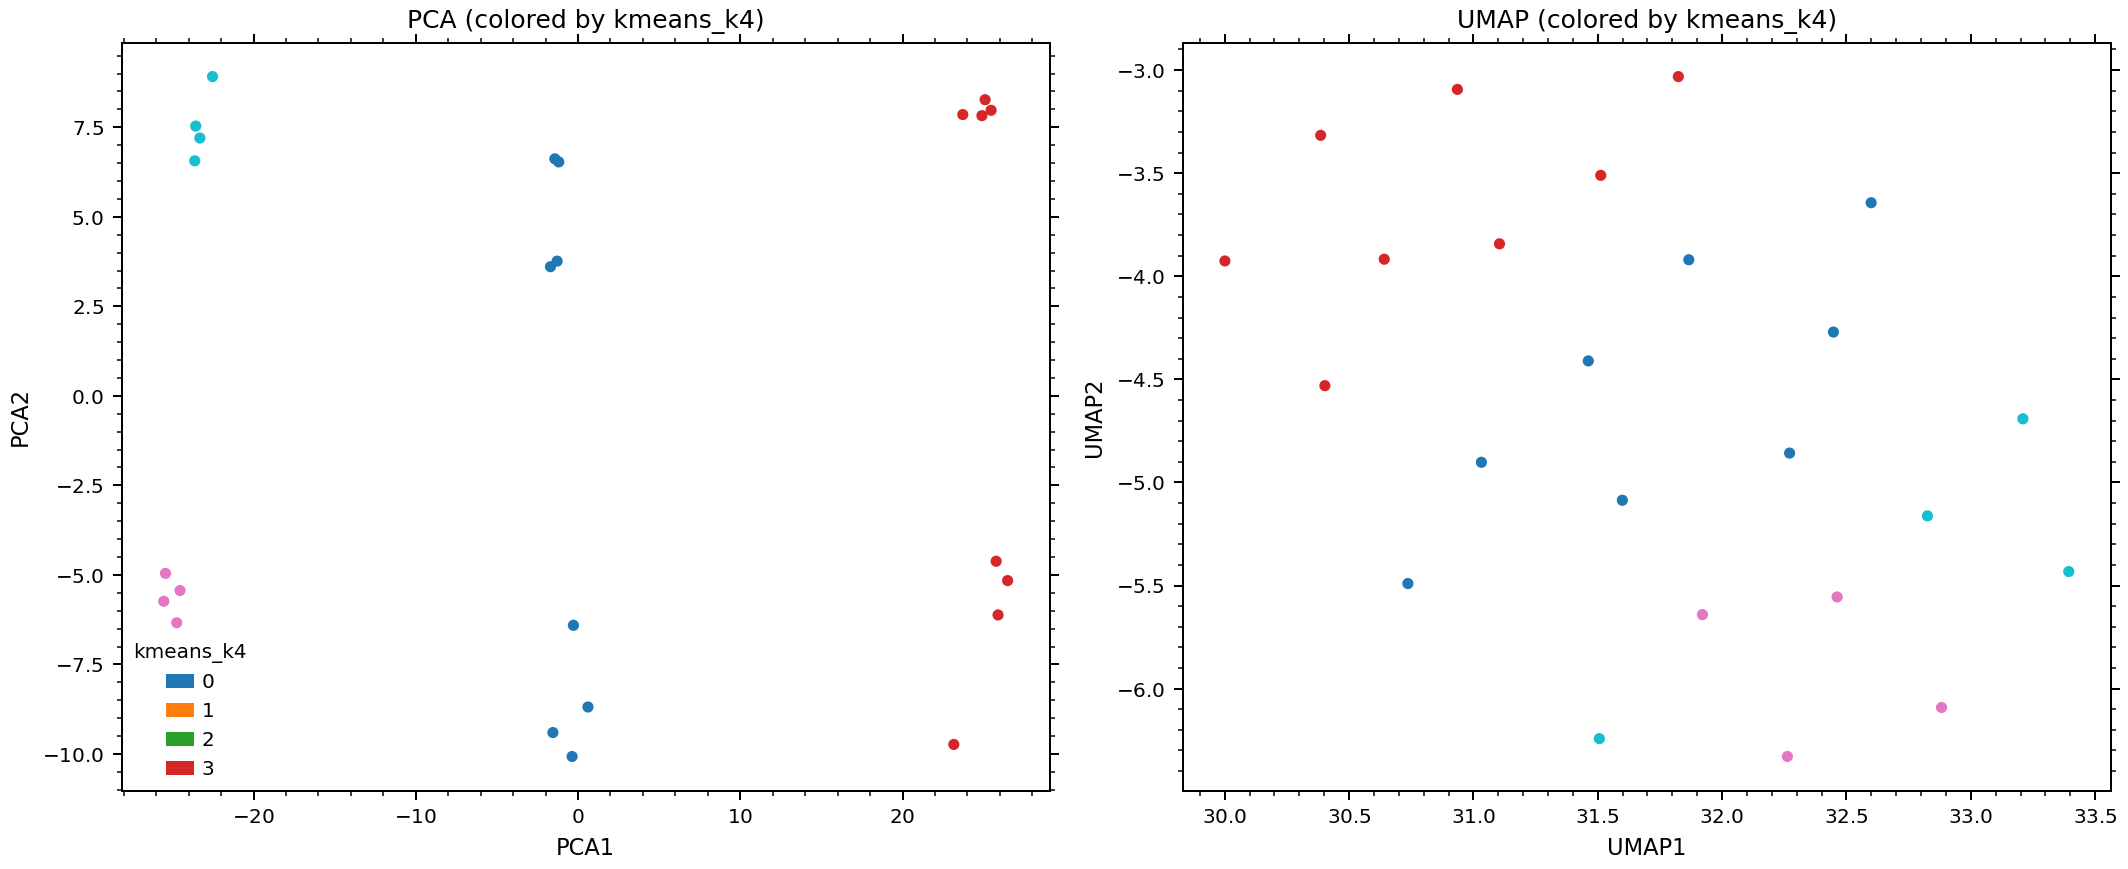

In [8]:
container = reduce_pca(
    container,
    assay_name="proteins",
    base_layer="imputed",
    n_components=20,
)

has_umap = True
try:
    container = reduce_umap(
        container,
        assay_name="pca",
        base_layer="X",
        n_neighbors=15,
        min_dist=0.2,
    )
except ModuleNotFoundError:
    has_umap = False
    print("UMAP dependency not installed, skip UMAP step.")

container = cluster_kmeans(
    container,
    assay_name="pca",
    base_layer="X",
    n_clusters=4,
    key_added="kmeans_k4",
)

print(container.obs["kmeans_k4"].value_counts())
plot_reduction_summary(container, pca_assay_name="pca", cluster_col="kmeans_k4")

if has_umap:
    plot_embedding_panels(
        container,
        assay_names=("pca", "umap"),
        layer="X",
        color_by="kmeans_k4",
        figsize=(12, 5),
    )
else:
    plot_embedding_panels(
        container,
        assay_names=("pca",),
        layer="X",
        color_by="kmeans_k4",
        figsize=(6, 5),
    )
plt.show()

## 8. 可视化与历史记录

Recent operations:
- aggregate_to_protein
- calculate_feature_qc_metrics
- filter_samples
- filter_low_quality_samples
- filter_features
- filter_features_by_missingness
- log_transform
- normalization_median_centering
- impute_knn
- reduce_pca
- reduce_umap
- cluster_kmeans


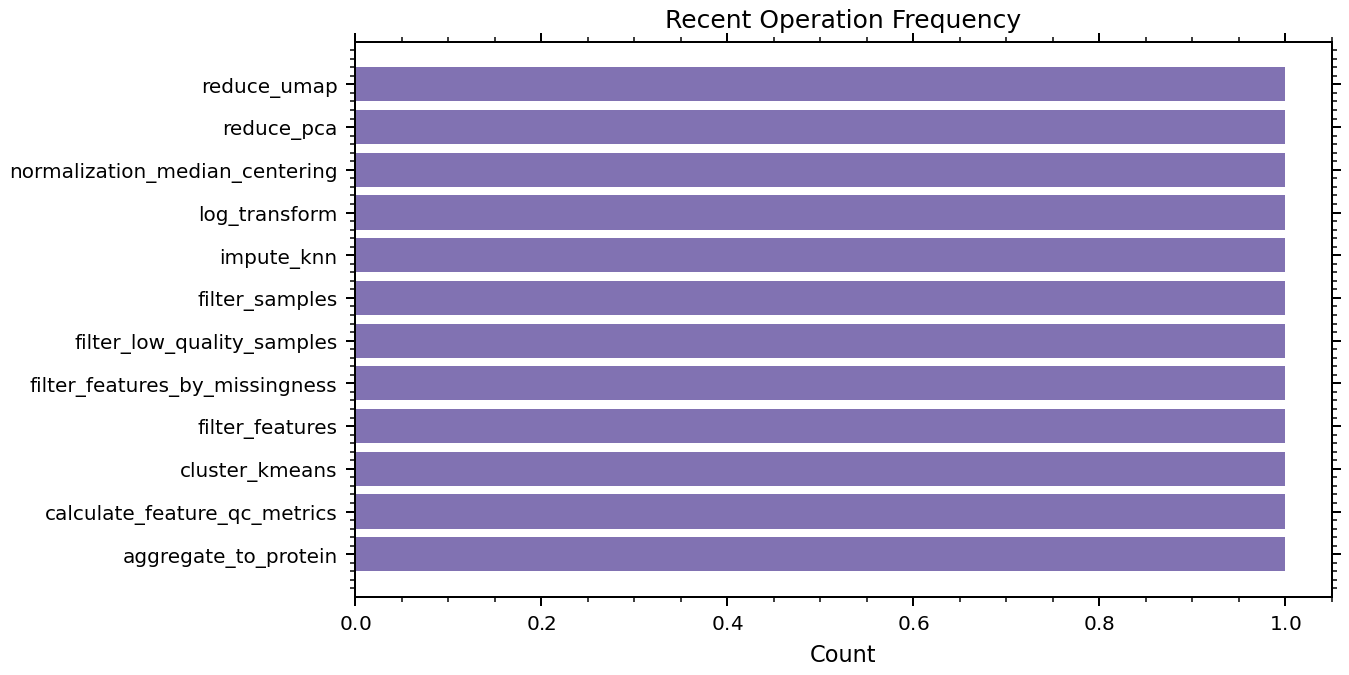

In [9]:
print("Recent operations:")
for log in container.history[-12:]:
    print(f"- {log.action}")

plot_recent_operations(container, n_recent=12)
plt.show()

## 9. 科研风格绘图参数优化（Publication Style）

基于当前 `viz.base` 的默认参数，可以直接得到更适合论文与汇报的图形风格：

- `PlotStyle.apply_style(theme="science", dpi=300)`：统一字体、线宽、导出分辨率与配色循环
- `heatmap(..., cbar_label=..., xtick_rotation=..., colorbar=...)`：提高矩阵图可读性
- `scatter(..., mask_style="explicit")`：显式区分测量值与缺失/插补点
- `violin(..., alpha=...)`：分组分布图保持清晰与克制


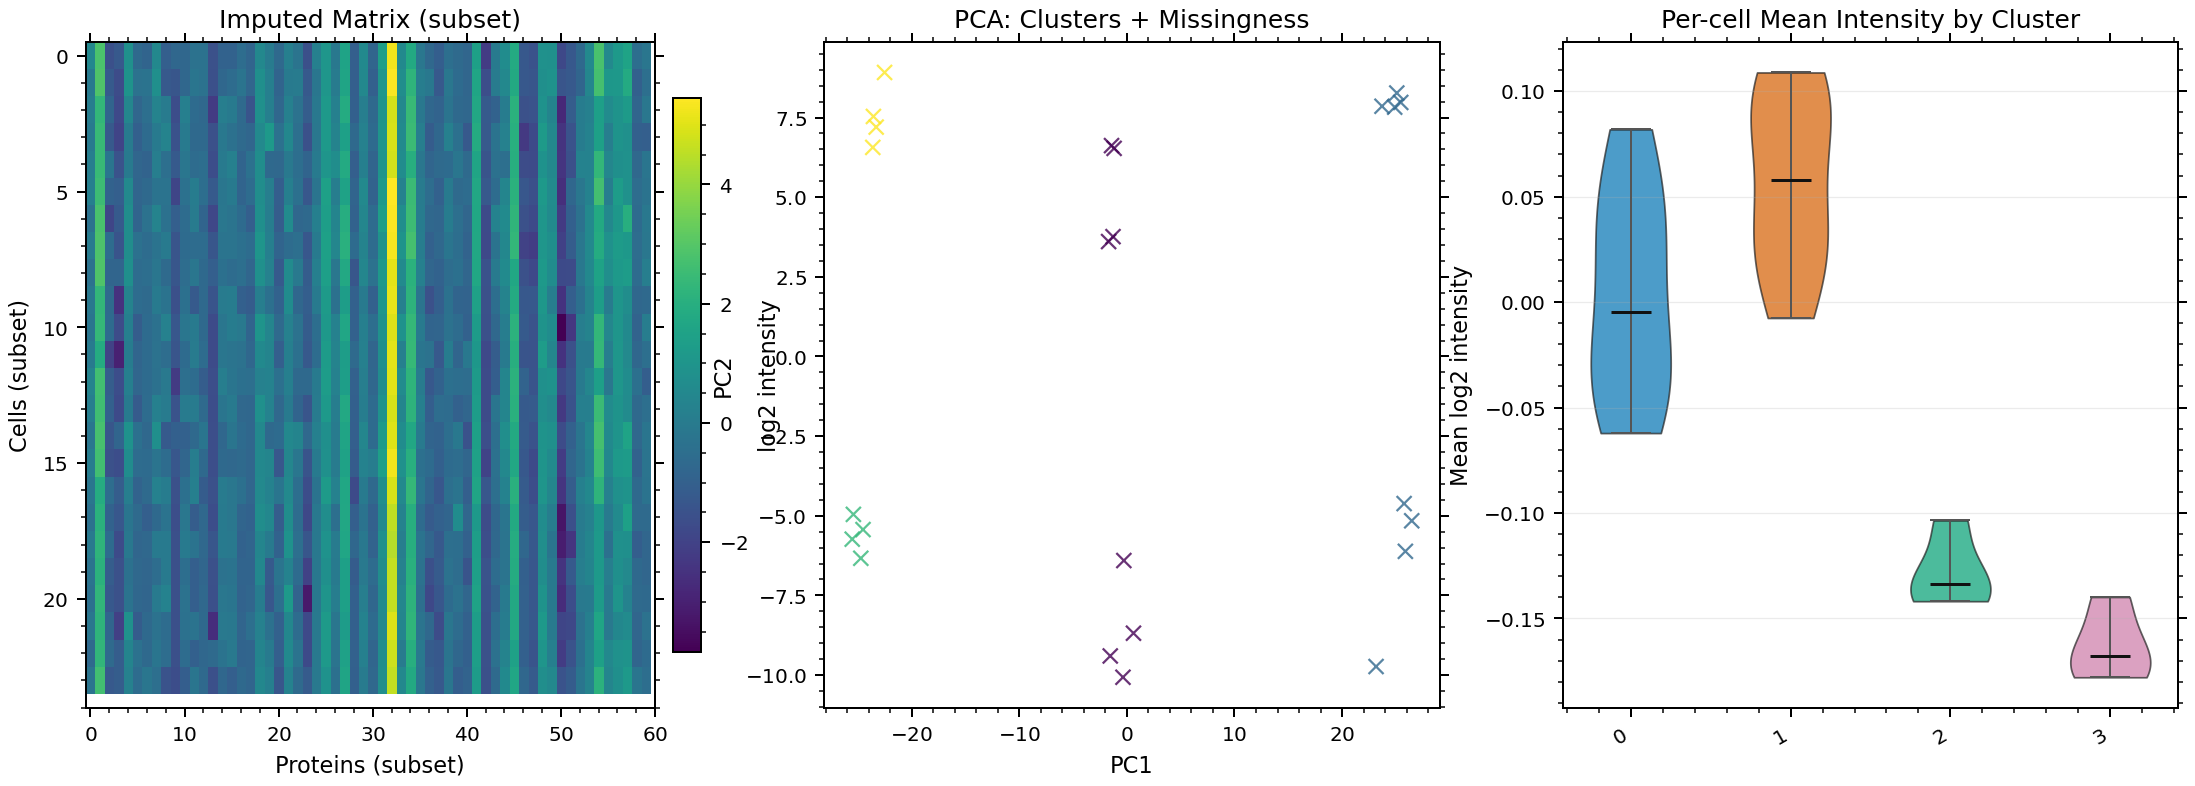

In [10]:
from scptensor.viz.base import PlotStyle, heatmap, scatter, violin

PlotStyle.apply_style(theme="science", dpi=300)

x_imputed = to_dense(container.assays["proteins"].layers["imputed"].X)
m_raw = container.assays["proteins"].layers["raw"].M
if m_raw is None:
    m_raw = np.zeros_like(x_imputed, dtype=np.int8)
else:
    m_raw = m_raw.toarray() if sp.issparse(m_raw) else np.asarray(m_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# 1) Heatmap: 子矩阵 + mask hatch + colorbar label
n_rows = min(40, x_imputed.shape[0])
n_cols = min(60, x_imputed.shape[1])
heatmap(
    x_imputed[:n_rows, :n_cols],
    m=m_raw[:n_rows, :n_cols],
    ax=axes[0],
    title="Imputed Matrix (subset)",
    cbar_label="log2 intensity",
    xtick_rotation=0,
)
axes[0].set_xlabel("Proteins (subset)")
axes[0].set_ylabel("Cells (subset)")

# 2) Scatter: PCA + explicit missing/imputed markers
pca_x = np.asarray(container.assays["pca"].layers["X"].X)
cluster_labels = container.obs["kmeans_k4"].to_numpy().astype(str)
_, cluster_codes = np.unique(cluster_labels, return_inverse=True)
sample_has_missing = (m_raw != 0).any(axis=1).astype(np.int8)
scatter(
    pca_x[:, :2],
    c=cluster_codes,
    m=sample_has_missing,
    mask_style="explicit",
    ax=axes[1],
    title="PCA: Clusters + Missingness",
    xlabel="PC1",
    ylabel="PC2",
    s=36,
)

# 3) Violin: 每个簇的细胞平均强度分布
violin_data = []
violin_labels = []
for label in np.unique(cluster_labels):
    mask = cluster_labels == label
    per_cell_mean = np.nanmean(x_imputed[mask], axis=1)
    violin_data.append(per_cell_mean)
    violin_labels.append(str(label))

violin(
    violin_data,
    violin_labels,
    ax=axes[2],
    title="Per-cell Mean Intensity by Cluster",
    ylabel="Mean log2 intensity",
    alpha=0.7,
)

plt.show()

## 小结

本教程按当前模块完成了完整主线：

- I/O：`load_quant_table` / `load_diann` / `load_spectronaut` / `load_peptide_pivot`
- 聚合：`aggregate_to_protein`（肽段层 -> 蛋白层）
- QC：`calculate_sample_qc_metrics` / `calculate_feature_qc_metrics` / 过滤
- 预处理：`log_transform` + `norm_median` + `impute_knn`
- 下游：`reduce_pca` / `reduce_umap` / `cluster_kmeans`
- 可视化：workflow 级 summary + `viz.base` 科研风格参数调优（heatmap/scatter/violin）

建议下一步：在同一流程上尝试 `tutorial/autoselect_tutorial.ipynb` 做方法自动选择与报告输出。
